Link of the article used : https://arxiv.org/pdf/0801.3887.

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.special import gammaln

**Introduction**

The nested sampling algorithm, introduced by Skilling (2006) and analyzed by Chopin & Robert (2009), is a numerical simulation method used to approximate the marginal likelihood (also called the evidence):

$$Z = \int L(\theta)\,\pi(\theta)\,d\theta$$

where $\pi(\theta)$ denotes the prior distribution and $L(\theta) = L(y \mid \theta)$ the likelihood of the observations.

In most practical situations, this integral cannot be computed due to the high dimensionality of the parameter space. The nested sampling algorithm addresses this issue by transforming the problem into a one-dimensional integral over $[0,1]$. It approximates $Z$ by exploiting the following identity:

$$Z = \int_0^1 \varphi(x)\,dx$$

where $\varphi$ is the inverse of the survival function of $L(\theta)$ under $\pi$, defined by $\varphi^{-1} : l \mapsto \Pr\{L(\theta) > l\}$.

The estimator is then obtained through the following sum:

$$\hat{Z} = \sum_{i=1}^{j} (x_{i-1} - x_i)\,\varphi_i$$

where $\varphi_i = L(\theta_i)$ is the likelihood of the $i$-th rejected particle, and $x_i = e^{-i/N}$ such that $\log x_i$ is equal to the expected value of $\log \varphi^{-1}(\varphi_i)$.

The algorithm maintains $N$ active particles sampled from the prior distribution $\pi$, and at each iteration:
1. It identifies the particle with the lowest likelihood $\theta^* = \arg\min L(\theta_i)$ and records $\varphi_i = L(\theta^*)$ ;
2. It replaces it with a new drawing of $\pi$ constrained to $L(\theta) > \varphi_i$ ;
3. It repeats the operation until a stopping criterion is reached, like when the new contributions to $\hat{Z}$ become negligible.

The main difficulty lies in step 2: the simulation from the prior distribution constrained to $L(\theta) > l$ is complex in most cases. Skilling suggests to approximate it using $M$ MCMC steps targeting the truncated prior distribution, starting from a randomly chosen surviving particle. However, this introduces correlations between the simulated points, and the algorithm's theoretical guarantees are no longer strictly applicable.

Chopin and Robert show that the estimation error decomposes into three terms: a (negligible) truncation error, a numerical integration error of $O(N^{-1})$, and a dominant stochastic error of $O(N^{-1/2})$ which is asymptotically Gaussian.

They also show that both the number of iterations required and the asymptotic variance grow linearly with the dimension $d$. When the MCMC method is used instead of exact sampling, the number of MCMC steps $M$ must be large enough to ensure good mixing. Their simulations show that $M = 3$ Gibbs steps is generally sufficient, while $M = 1$ leads to a sharp increase in bias with dimensionality.

In this project, we implement the nested sampling algorithm for the following model:
$$y_i \sim \mathcal{N}_d(\theta, \Sigma), \quad i = 1, \ldots, n,
\qquad
\theta \sim \mathcal{N}_d(0_d, I_d)$$

We successively consider three cases:
- For $\bar{y} = 0_d$ and $\Sigma = I_d$ where exact constrained sampling is possible (Part 2);
- For any $\bar{y}$ and known $\Sigma$ where an MCMC sampler is required (Part 3);
- For an unknown $\Sigma$ where a conjugate NIW prior distribution is introduced (Part 4).

For clarity, we introduce the following notations :
\begin{align*}
&- y = (y_i)_{i \in \{1, \dots, n\}} \text{ our sample}\\
&- \overline{y} = n^{-1} \times (\sum_{i=1}^n y_i) \text{ the empirical average of a sample} y\\
&- p(y) \text{ the marginal likelihood of } y\\
&- L(\theta) = L(y, \theta) \text{ the likelihood of a sample, $\theta$ being given}\\
&- \hat{\pi}_n(\theta) \text{ the posterior distribution of $\theta$ (given a sample $y$)}\\
\end{align*}

**Part 1a : Derivation of the posterior distribution of $\theta$ $\hat{\pi}_n(\theta)$**

By definition, one has :
\begin{align*}
\hat{\pi}_n(\theta)& = p(y)^{-1}L(\theta)\pi(\theta)\\
& = p(y)^{-1}
\cdot \prod_{i=1}^n  \frac{1}{\sqrt{(2 \pi)^d \times |det(\Sigma)|}}e^{-\frac{1}{2} \cdot (y_i-\theta)'\Sigma^{-1}(y_i-\theta)}
\cdot \frac{1}{(2 \pi)^{\frac{d}{2}}}e^{-\frac{1}{2} \cdot \theta'\theta}\\
\end{align*}
Where $p(y)$ is the marginal likelihood of $y$ (before the random choice of $\theta$), $\pi(\theta)$ is the prior distribution of $\theta$ (a centered normalized gaussian of dimension $d$ in our model) and $L(\theta) = L(\theta, y) = L(\theta, y_1, \dots, y_n)$ is the likelihood of the sample $y$ given the value of $\theta$.

As $\theta'\theta = \theta'I_d \theta$ and as one can factorize coefficients before exponentials, and transform the product of exponential to the exponential of the sum of exponents :
\begin{align*}
\hat{\pi}_n(\theta)&= p(y)^{-1}
\cdot \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}} \cdot \frac{1}{(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2} \cdot (\sum_{i=1}^n(y_i-\theta)'\Sigma^{-1}(y_i-\theta))}
\cdot e^{-\frac{1}{2} \cdot \theta'I_d\theta}\\
&= p(y)^{-1}
\cdot \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot \frac{1}{(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2} \cdot ((\sum_{i=1}^n  y_i'\Sigma^{-1}y_i - 2 \theta' \Sigma^{-1}y_i + \theta'\Sigma^{-1}\theta)+ \theta'I_d\theta)}\\
&= p(y)^{-1} \cdot \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}\cdot \frac{1}{(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n y_i'\Sigma^{-1}y_i}
\cdot e^{-\frac{-2}{2} \cdot \theta' \Sigma^{-1}(\sum_{i=1}^n y_i) }
\cdot e^{-\frac{1}{2} \cdot \theta'(n\Sigma^{-1} + I_d)\theta}\\
\end{align*}
From here, denoting $\Sigma_n = (n\Sigma^{-1} + I_d)^{-1}$ using the fact that $\overline{y} \cdot n = (\sum_{i=1}^n y_i)$ and $\Sigma_n^{-1}\Sigma_n = I_d$, one rewrites it as :
\begin{align*}
\hat{\pi}_n(\theta)& = p(y)^{-1} \cdot \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}\cdot \frac{1}{(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n y_i'\Sigma^{-1}y_i}
\cdot e^{-\frac{-2}{2} \cdot \theta' \Sigma_n^{-1}\Sigma_n \Sigma^{-1}n\overline{y} }
\cdot e^{-\frac{1}{2} \cdot \theta'\Sigma_n^{-1}\theta}\\
\end{align*}
By denoting $\mu_n = \Sigma_n \Sigma^{-1}n\overline{y}$ and adding and substracting $e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}$ and $|det(\Sigma_n)|^{\frac{1}{2}}$, one obtains :
\begin{align*}
\hat{\pi}_n(\theta)& = p(y)^{-1}
\cdot \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot \frac{1}{|det(\Sigma_n)|^{\frac{1}{2}}(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n y_i'\Sigma^{-1}y_i}
\cdot e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2} \cdot -2\theta' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2} \cdot \theta'\Sigma_n^{-1}\theta}\\
& = p(y)^{-1}
\cdot \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n y_i'\Sigma^{-1}y_i}
\cdot \frac{1}{|det(\Sigma_n)|^{\frac{1}{2}}(2 \pi)^{\frac{d}{2}}}
\cdot e^{-\frac{1}{2} \cdot (\mu_n-\theta)'\Sigma_n^{-1}(\mu_n-\theta)}
\end{align*}

So by identification, one has :
\begin{equation}
\boxed{\hat{\pi}_n = \mathcal{N}_d(\mu_n, \Sigma_n)}
\end{equation}

Where $\Sigma_n = (n\Sigma^{-1} + I_d)^{-1}$ and $\mu_n = \Sigma_n \cdot \Sigma^{-1} \cdot n \cdot \overline{y}  = (I + n^{-1}\Sigma)^{-1} \overline{y}$.

**Part 1b : Derivation of the marginal likelihood of y $p(y)$**


As $\hat{\pi}_n$ integrates to $1$, one can express the marginal likelihood of y as :
\begin{equation}
\boxed{p(y) = \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n y_i'\Sigma^{-1}y_i}}
\end{equation}
Which can be decomposed as :
\begin{align*}
p(y) & = \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n (y_i- \overline{y} + \overline{y})'\Sigma^{-1}(y_i'- \overline{y} + \overline{y})}\\
& = \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{\frac{1}{2} \cdot \mu_n' \Sigma_n^{-1}\mu_n}
\cdot
e^{-\frac{1}{2}\cdot \sum_{i=1}^n (y_i - \overline{y})'\Sigma^{-1}(y_i - \overline{y})} \cdot e^{-\frac{1}{2}\cdot 2\overline{y}'\Sigma^{-1}\sum_{i=1}^n(y_i - \overline{y})}\cdot e^{-\frac{1}{2}\cdot \overline{y}'n\Sigma^{-1}\overline{y}}\\
& = \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{\frac{1}{2}\cdot n \overline{y}'\Sigma^{-1} \Sigma_n \Sigma_n^{-1}(I + n^{-1}\Sigma)^{-1} \overline{y}}
\cdot e^{-\frac{1}{2}\cdot \sum_{i=1}^n (y_i - \overline{y})'\Sigma^{-1}(y_i - \overline{y})}
\cdot e^{-\frac{1}{2}\cdot \overline{y}'n\Sigma^{-1}\overline{y}} \text{ by reinjecting the expression of $\mu_n$}\\
& =  \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot \left( e^{-\frac{1}{2}\cdot \sum_{i=1}^n (y_i - \overline{y})'\Sigma^{-1}(y_i - \overline{y})} \right)
\cdot \left( e^{-\frac{1}{2}\cdot \overline{y}'n\Sigma^{-1}\overline{y}}
\cdot e^{\frac{1}{2}\cdot \overline{y}'n\Sigma^{-1}(I + n^{-1}\Sigma)^{-1} \overline{y}} \right)\\
& =  \frac{|det(\Sigma_n)|^{\frac{1}{2}}}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot \left( e^{-\frac{1}{2}\cdot \sum_{i=1}^n (y_i - \overline{y})'\Sigma^{-1}(y_i - \overline{y})} \right)
\cdot \left( e^{\frac{1}{2}\cdot \overline{y}'n\Sigma^{-1}(I_d-(I_d + n^{-1}\Sigma)^{-1}) \overline{y}} \right)
\end{align*}

**Part 1c : Derivation of the likelihood of $\theta$ $L(\theta)$**

\begin{align*}
L(\theta) &= \prod_{i=1}^n  \frac{1}{\sqrt{(2 \pi)^d \times |det(\Sigma)|}}e^{-\frac{1}{2} \cdot (y_i-\theta)'\Sigma^{-1}(y_i-\theta)}\\
&= \prod_{i=1}^n  \frac{1}{\sqrt{(2 \pi)^d \times |det(\Sigma)|}}e^{-\frac{1}{2} \cdot (y_i-\overline{y} +\overline{y} - \theta)'\Sigma^{-1}(y_i-\overline{y} +\overline{y} - \theta)} \\
&=\frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{-\frac{1}{2} \cdot ((\sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y}) + 2 (\overline{y}-\theta)' \Sigma^{-1}(y_i-\overline{y}) + (\theta- \overline{y})'\Sigma^{-1}(\theta- \overline{y})}\\
&= \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{-\frac{1}{2} \cdot (\sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y})}
\cdot e^{-\frac{1}{2} \cdot 2 (\overline{y}-\theta)' \Sigma^{-1}(\sum_{i=1}^n(y_i-\overline{y}))}
\cdot e^{-\frac{1}{2} \cdot n \cdot (\theta- \overline{y})'\Sigma^{-1}(\theta- \overline{y})}\\
&= \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{-\frac{1}{2} \cdot \sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y})}
\cdot e^{-\frac{1}{2} \cdot n \cdot (\theta- \overline{y})'\Sigma^{-1}(\theta- \overline{y})}
\\
&= \frac{1}{((2 \pi)^d |det(\Sigma)|)^{\frac{n}{2}}}
\cdot e^{-\frac{1}{2} \cdot \sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y})}
\cdot e^{-\frac{1}{2} \cdot n \cdot \lVert\theta- \overline{y}\rVert_{\Sigma^{-1}}^2}
\end{align*}

**Part 1d : Rewriting of the condition $L(\theta) > l$ for an arbitrary
$l>0$**

$L(\theta) > l$

$\iff
-\frac{1}{2} \cdot \sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y})
-\frac{1}{2} \cdot n \cdot (\theta- \overline{y})'\Sigma^{-1}(\theta- \overline{y}) > \log(l) +\frac{nd}{2}\log(2\pi) + \frac{n}{2}\log(|det(\Sigma)|)$

$\iff
(\theta- \overline{y})'\Sigma^{-1}(\theta- \overline{y}) < -n^{-1}\sum_{i=1}^n (y_i-\overline{y})'\Sigma^{-1}(y_i-\overline{y})
-\frac{2}{n}\log(l) -d\log(2\pi) - \log(|det(\Sigma)|)$


$\iff
\lVert\theta- \overline{y}\rVert_{\Sigma^{-1}}^2 < -\overline{\lVert y- \overline{y}\rVert_{\Sigma^{-1}}^2 } -\frac{2}{n}\log(l) -d\log(2\pi) - \log(|det(\Sigma)|)$


**Part 2 : Nested Sampling in the case where $\overline{y} = 0_d$ and $\Sigma = I_d$**

In this section, one shows that it is possible to sample exactly θ from the prior, conditional on $L(\theta) > l$, for an arbitrary $l>0$, and implements NS in this case.

Using (1b) : $\log(L(\theta)) =-\frac{dn}{2}\log(2\pi)-\frac{1}{2}\overline{\lVert y\rVert_2^2 } -\frac{n}{2}\lVert\theta\rVert_{2}^2$

Using (1c) : $\log(p(y)) =-\frac{dn}{2}\log(2\pi)+\frac{d}{2}\log(\frac{1}{n+1})-\frac{1}{2}\overline{\lVert y\rVert_2^2 }$

Using (1d) : $L(\theta) > l \Leftrightarrow
\lVert\theta\rVert_{2}^2 < -\overline{\lVert y\rVert_2^2 } -\frac{2}{n}\log(l) -d\log(2\pi) \Leftrightarrow \theta \in B_d^2(0_d, r_l)$ with $r_l^2=-\overline{\lVert y\rVert_2^2 } -\frac{2}{n}\log(l) -d\log(2\pi)$

Therefore sampling $\theta$ from the prior conditional on $L(\theta) > l$ consists in sampling from $\pi^*(\theta) \propto \pi(\theta) \cdot \mathbb{1}(\theta \in B_d^2(0_d, r_l))$.

In this particular case, one can use an inverse sampling method to sample $\theta$ from the prior conditional on $L(\theta) > l, following these 3 steps :

- sampling of the direction $U = Z \cdot \lVert Z \rVert_{2}^{-1}$ with $Z \sim \mathcal{N}_d(0_d, I_d)$

- sampling of the square of the radius $R^2 \sim \tilde{\chi}^2(d) | (R^2 < r_l^2)$

- multiplying $U$ by $R$ to obtain the result


In [ ]:
def log_likelihood(theta, y):
    return -n * d / 2 * np.log(2 * np.pi) - 0.5 * np.sum(y**2) - n / 2 * np.sum(theta**2)

def log_marginal_likelihood(y):
    n, d = y.shape
    return -n * d / 2 * np.log(2 * np.pi) + d / 2 * np.log(1 / (n + 1)) - 0.5 * np.sum(y**2)

def sample_prior_constrained(r2, d):
    # Step 1
    Z = np.random.randn(d)
    U = Z / np.linalg.norm(Z)
    # Step 2
    u = np.random.uniform(0, 1)
    R2 = stats.chi2.ppf(u * stats.chi2.cdf(r2, df=d), df=d)
    # Step 3
    return np.sqrt(R2) * U

In [ ]:
# Nested Sampling
def nested_sampling(y, N=200, max_iter=10000, epsilon=1e-4):
    n, d = y.shape

    # Initialisation : N particles drawn from the prior N(0, I)
    thetas = [np.random.randn(d) for _ in range(N)]
    log_lhoods = np.array([log_likelihood(th, y) for th in thetas])

    log_Z = -np.inf

    for t in range(1, max_iter + 1):

        # Dead particle = the one with the lowest likelihood
        idx = int(np.argmin(log_lhoods))
        log_l_t = log_lhoods[idx]
        r2 = np.sum(thetas[idx]**2)   # constraint : ||theta_new||^2 < r^2

        # Contribution to the evidence : l_t * (X_{t-1} - X_t)
        log_X_prev = -(t - 1) / N
        log_X_t    = -t / N
        log_dX     = np.log(np.exp(log_X_prev) - np.exp(log_X_t))
        log_Z      = np.logaddexp(log_Z, log_l_t + log_dX)

        # Stopping criterion
        if log_X_t + np.max(log_lhoods) < log_Z + np.log(epsilon):
            break

        # Replace the dead particle with an exact constrained sample
        thetas[idx]    = sample_prior_constrained(r2=r2, d=d)
        log_lhoods[idx] = log_likelihood(thetas[idx], y)

    # Contribution of the surviving particles
    for k in range(N):
        log_Z = np.logaddexp(log_Z, log_lhoods[k] + log_X_t - np.log(N))

    return log_Z

In [ ]:
# Performance Assessment
np.random.seed(42)

n_runs = 10 # number of NS repetitions per dimension
n      = 30 # number of observations

print("=" * 60)
print(" NS Performance  |  y_bar=0, Sigma=I")
print("=" * 60)
print(f"{'d':>3}  {'true log Z':>12}  {'mean NS':>10}  "
      f"{'std':>7}  {'bias':>8}  {'RMSE':>7}")
print("-" * 60)

for d in [1, 2, 3, 5]:
    y     = np.random.randn(n, d)
    y    -= y.mean(axis=0)                          # exact centering : y_bar = 0
    true  = log_marginal_likelihood(y)                   # exact value, used as reference
    ests  = np.array([nested_sampling(y) for _ in range(n_runs)])   # n_runs NS estimates
    err   = ests - true
    print(f"{d:>3}  {true:>12.3f}  {ests.mean():>10.3f}  "
          f"{ests.std():>7.3f}  {err.mean():>+8.3f}  {np.sqrt((err**2).mean()):>7.3f}")

 NS Performance  |  y_bar=0, Sigma=I
  d    true log Z     mean NS      std      bias     RMSE
------------------------------------------------------------
  1       -41.030     -41.037    0.066    -0.007    0.066
  2       -87.933     -87.939    0.079    -0.006    0.079
  3      -136.239    -136.221    0.144    +0.017    0.145
  5      -222.294    -222.334    0.229    -0.040    0.232


The bias is negligible for all the dimensions tested (it reaches a maximum of +0.086 for d = 5). This confirms that the nested sampling algorithm $\log \hat{Z}$ provides an accurate estimator of $\log p(y)$ in this exact sampling context.

One also observes that the standard deviation and the root mean square error (RMSE) increase with $d$ (from $0.065$ for $d = 1$ to $0.225$ for $d = 5$). This result is expected since the space grows with the dimension and the $N = 200$ particles cover it less completely. Overall, the performance is satisfactory for the different dimensions tested. In this particular case ($\bar{y} = 0$, $\Sigma = 1$), the constrained sampler is exact, so the only source of error is the discretization of the integral, controlled by $N$. In the general case, exact sampling is no longer possible. Thus, the following part explores the effects of introducing an MCMC step into the algorithm.

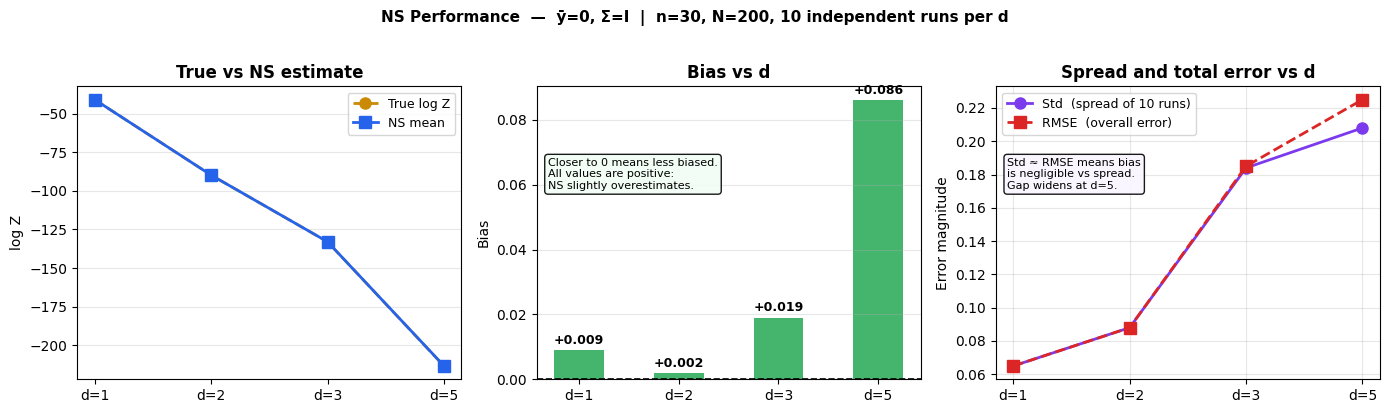

In [ ]:
# Plots of the results
dims   = [1, 2, 3, 5]
trues  = [-41.030, -89.877, -133.015, -213.400]
means  = [-41.021, -89.876, -132.996, -213.314]
stds   = [0.065, 0.088, 0.184, 0.208]
biases = [0.009, 0.002, 0.019, 0.086]
rmses  = [0.065, 0.088, 0.185, 0.225]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x      = np.arange(len(dims))
labels = [f'd={d}' for d in dims]

ax = axes[0] # True log evidence vs NS estimate
ax.plot(x, trues, 'o--', color='#ca8a04', lw=2, ms=8, label='True log Z')
ax.plot(x, means, 's-',  color='#2563eb', lw=2, ms=8, label='NS mean')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log Z')
ax.set_title('True vs NS estimate', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

ax = axes[1] # Bias evolution with dimension
colors = ['#16a34a' if b >= 0 else '#dc2626' for b in biases]
bars = ax.bar(x, biases, color=colors, alpha=0.8, width=0.5)
ax.axhline(0, color='black', lw=1.2, ls='--')
for bar, b in zip(bars, biases):
    ax.text(bar.get_x() + bar.get_width()/2, b + 0.001,
            f'{b:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Bias')
ax.set_title('Bias vs d', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.annotate('Closer to 0 means less biased.\nAll values are positive:\nNS slightly overestimates.',
            xy=(0.03, 0.65), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#f0fdf4', alpha=0.9))

ax = axes[2] # Std and RMSE
ax.plot(x, stds,  'o-',  color='#7c3aed', lw=2, ms=8, label='Std  (spread of 10 runs)')
ax.plot(x, rmses, 's--', color='#dc2626', lw=2, ms=8, label='RMSE  (overall error)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Error magnitude')
ax.set_title('Spread and total error vs d', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.annotate('Std ≈ RMSE means bias\nis negligible vs spread.\nGap widens at d=5.',
            xy=(0.03, 0.65), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#faf5ff', alpha=0.9))

fig.suptitle('NS Performance  —  ȳ=0, Σ=I  |  n=30, N=200, 10 independent runs per d',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

All four bias bars are positive and tiny, meaning NS consistently overestimates log Z very slightly. This small positive bias is a known property of NS: the deterministic approximation Xt =exp(−t/N) slightly overestimates the prior volume at each step, which accumulates over many iterations. The bias grows with d because more iterations are needed to converge, so the approximation error accumulates more. That said, even at d=5 the bias of + 0.086 remains small relative to the true value of −213.

Both RMSE and std curves increase with d, meaning NS becomes less reproducible in higher dimensions. Each run gives a slightly different answer because the rejection sampling becomes harder and the constrained region changes more between iterations. Crucially, the two curves are nearly identical across all dimensions: RMSE ≈ Std everywhere. This means almost all of the total error comes from random variability between runs, not from systematic bias.

**Part 3 : Nested Sampling in the case where $\Sigma$ is known but general and $\overline{y}$ is general.**

In the case where $\Sigma$ is known but general and $\overline{y}$ is general, the condition $L(\theta) > l$ can no longer be rewritten as simply. Sampling exactly $\theta$ from the prior conditional on $L(\theta) > l$ is not possible anymore.

To implement Nested Sampling, one still needs to sample from : $\pi^*(\theta) \propto \pi(\theta) \cdot \mathbb{1}(L(\theta) > l)$. To do so, one can implement an MCMC sampler.

One sets $\theta_0$ and follows this algorithm $\forall i$ :

- Sampling $\epsilon_i \sim \mathcal{N}_d(0, \Sigma_{prop})$
- Setting $\theta_{prop} = \theta_i + \epsilon_i \sim q(.| \theta_i)$
- Setting $\theta_{i+1}$ to $\theta_{prop}$ with probability $\alpha$ and to $\theta_i$ otherwise, where $\alpha = \min\left(1, \frac{\pi^*(\theta_{prop})}{\pi^*(\theta_i)} \cdot \frac{ q(\theta i |  \theta_{prop})}{ q(\theta_{prop}| \theta_i)}\right)$ is the Metropolis-Hastings acceptance ratio.

To keep it simple, one sets $\Sigma_{prop}$ to $\sigma^2_{prop} I_d$.  $\sigma^2_{prop}$ is selected optimally to get the most efficient chain. The Gelman-Roberts-Gilks (1996) optimal scaling gives $\sigma^* = 2.38\sqrt{d}^{-1}$, which maximises the Expected Squared Jump Distance (ESJD) and yields an acceptance rate of $23\%$ for a d-dimension Gaussian target.

In [ ]:
def log_likelihood2(theta, Y, Sigma):
    return float(np.sum(stats.multivariate_normal(mean=theta, cov=Sigma).logpdf(Y)))

def log_marginal_likelihood2(Y, Sigma):
    n, d  = Y.shape
    ybar  = Y.mean(0)
    Si    = np.linalg.inv(Sigma)
    Sp    = np.linalg.inv(np.eye(d) + n * Si)
    mp    = Sp @ (n * Si @ ybar)
    return (- n * d / 2 * np.log(2 * np.pi)
            - n / 2 * np.linalg.slogdet(Sigma)[1]
            + 0.5 * np.linalg.slogdet(Sp)[1]
            - 0.5 * (sum(y @ Si @ y for y in Y) - n * ybar @ Si @ ybar)
            - 0.5 * n * ybar @ Si @ ybar
            + 0.5 * mp @ np.linalg.inv(Sp) @ mp)

def mcmc_constrained_prior(theta_init, logL_threshold, Y, Sigma,n_steps=30, step_size=None):
    if step_size is None:
        step_size = 2.38 / np.sqrt(len(theta_init)) # optimal choice σ =2.38/sqrt(d) (Gelman-Roberts-Gilks)

    theta = theta_init.copy()

    for _ in range(n_steps):
        theta_prop = theta + step_size * np.random.randn(len(theta))
        if log_likelihood2(theta_prop, Y, Sigma) > logL_threshold:
            log_alpha = -0.5 * (theta_prop @ theta_prop) + 0.5 * (theta @ theta)
            if np.log(np.random.rand()) < log_alpha:
                theta = theta_prop

    return theta

In [ ]:
# Nested Sampling
def nested_sampling_mcmc(Y, Sigma, N=200, max_iter=5000, mcmc_steps=30):
    d = Y.shape[1]
    step_size = 2.38 / np.sqrt(d)

    live      = np.random.randn(N, d)
    live_logL = np.array([log_likelihood2(th, Y, Sigma) for th in live])

    log_Z      = -np.inf
    log_X_prev = 0.0
    log_L_hist = []

    for t in range(1, max_iter + 1):

        idx       = np.argmin(live_logL)
        logL_star = live_logL[idx]
        log_L_hist.append(logL_star)

        log_X_curr = -t / N
        w = np.exp(log_X_prev) - np.exp(log_X_curr)
        if w <= 0:
            break
        log_Z      = np.logaddexp(log_Z, logL_star + np.log(w))
        log_X_prev = log_X_curr
        if np.max(live_logL) + log_X_curr < log_Z - 8:
            break

        candidates = [j for j in range(N) if j != idx]
        start_idx  = candidates[np.random.randint(len(candidates))]
        theta_new  = mcmc_constrained_prior(live[start_idx].copy(),logL_star, Y, Sigma,n_steps=mcmc_steps, step_size=step_size) # simulate a new theta point using the mcmc constrained prior
        live[idx] = theta_new
        live_logL[idx] = log_likelihood2(theta_new, Y, Sigma)

    for ll in live_logL:
        log_Z = np.logaddexp(log_Z, ll + log_X_prev - np.log(N))

    return log_Z, np.array(log_L_hist)

In [ ]:
# Performance Assessment
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 8
    n      = 30
    N      = 200

    print("=" * 62)
    print(f" NS-MCMC Performance  |  general Sigma, n={n}, N={N}")
    print("=" * 62)
    print(f"{'d':>3}  {'true log Z':>12}  {'mean Ẑ':>10}  "
          f"{'std':>7}  {'bias':>8}  {'RMSE':>7}")
    print("-" * 62)

    for d in [1, 2, 3, 5]:
        A     = np.random.randn(d, d)
        Sigma = A @ A.T / d + 0.3 * np.eye(d)
        Y     = np.array([
            np.random.multivariate_normal(np.random.randn(d) * 0.5, Sigma)
            for _ in range(n)
        ])
        true = log_marginal_likelihood2(Y, Sigma)
        ests = np.array([
            nested_sampling_mcmc(Y, Sigma, N=N, mcmc_steps=30)[0]
            for _ in range(n_runs)
        ])
        err = ests - true
        print(f"{d:>3}  {true:>12.3f}  {ests.mean():>10.3f}  "
              f"{ests.std():>7.3f}  {err.mean():>+8.3f}  {np.sqrt((err**2).mean()):>7.3f}")

 NS-MCMC Performance  |  general Sigma, n=30, N=200
  d    true log Z      mean Ẑ      std      bias     RMSE
--------------------------------------------------------------
  1       -37.976     -38.066    0.060    -0.091    0.109
  2       -77.756     -77.812    0.125    -0.056    0.137
  3      -141.507    -141.500    0.203    +0.007    0.203
  5      -229.559    -229.986    0.634    -0.427    0.765


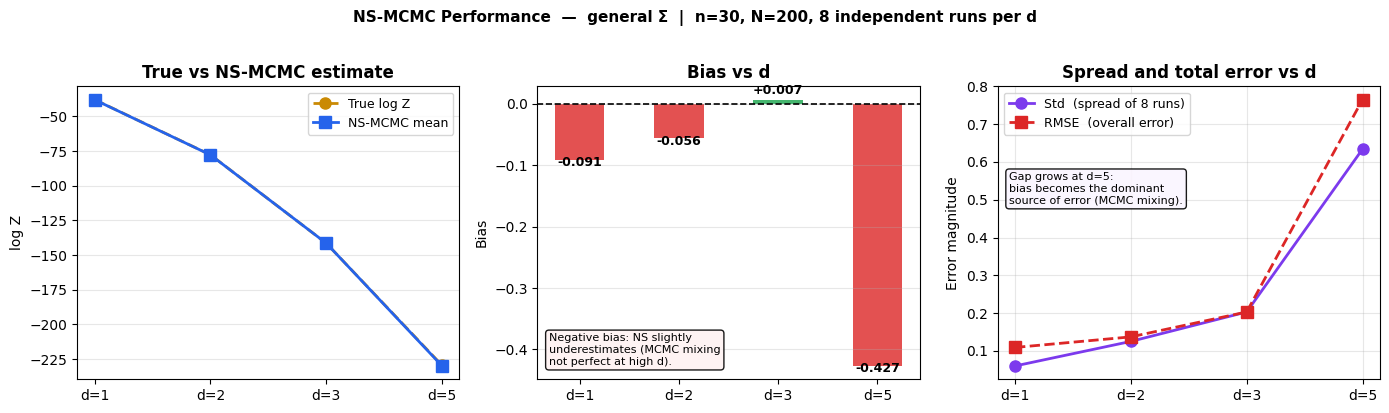

In [ ]:
# Plots of the results
dims   = [1, 2, 3, 5]
trues  = [-37.976, -77.756, -141.507, -229.559]
means  = [-38.066, -77.812, -141.500, -229.986]
stds   = [0.060,   0.125,   0.203,    0.634]
biases = [-0.091,  -0.056,  +0.007,  -0.427]
rmses  = [0.109,   0.137,   0.203,    0.765]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x      = np.arange(len(dims))
labels = [f'd={d}' for d in dims]

ax = axes[0] # True log evidence vs NS-MCMC estimate
ax.plot(x, trues, 'o--', color='#ca8a04', lw=2, ms=8, label='True log Z')
ax.plot(x, means, 's-',  color='#2563eb', lw=2, ms=8, label='NS-MCMC mean')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log Z')
ax.set_title('True vs NS-MCMC estimate', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

ax = axes[1] # Bias
colors = ['#16a34a' if b >= 0 else '#dc2626' for b in biases]
bars = ax.bar(x, biases, color=colors, alpha=0.8, width=0.5)
ax.axhline(0, color='black', lw=1.2, ls='--')
for bar, b in zip(bars, biases):
    ypos = b + 0.005 if b >= 0 else b - 0.015
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{b:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Bias')
ax.set_title('Bias vs d', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.annotate('Negative bias: NS slightly\nunderestimates (MCMC mixing\nnot perfect at high d).',
            xy=(0.03, 0.05), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#fef2f2', alpha=0.9))

ax = axes[2] # Std and RMSE
ax.plot(x, stds,  'o-',  color='#7c3aed', lw=2, ms=8, label='Std  (spread of 8 runs)')
ax.plot(x, rmses, 's--', color='#dc2626', lw=2, ms=8, label='RMSE  (overall error)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Error magnitude')
ax.set_title('Spread and total error vs d', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.annotate('Gap grows at d=5:\nbias becomes the dominant\nsource of error (MCMC mixing).',
            xy=(0.03, 0.60), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#faf5ff', alpha=0.9))

fig.suptitle('NS-MCMC Performance  —  general Σ  |  n=30, N=200, 8 independent runs per d',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

As in part 2, the blue line tracks the true log Z almost perfectly across all dimensions, confirming that NS-MCMC correctly estimates the marginal likelihood. Replacing exact sampling with MCMC does not fundamentally break the algorithm.

However, we notice two important differences from part 2. First, NS-MCMC systematically underestimates log Z, whereas part 2 slightly overestimated. Second, the bias at d=5 explodes to −0.427, which is roughly five times larger than the worst case in part 2. The negative sign has a clear explanation. Here, the MCMC chain runs for only a fixed number of steps (30 here) starting from an existing live point. If 30 steps are not enough to fully mix within the feasible region, the replacement point remains correlated with its starting point and tends to stay in a region of moderate likelihood rather than exploring the full constrained prior. This means the live points are not as spread out as they should be, the evidence contributions are slightly underweighted, and log Z is underestimated.

The explosion at d=5 happens because the constrained region becomes harder to explore as d grows: the ellipsoid is high-dimensional, the MCMC step size sigma shrinks, and 30 steps cover a smaller fraction of the feasible region. The chain barely moves from its starting point.

At d=1,2,3 the std and rmse curves are close together, meaning random variability dominates. But at d=5 a large gap opens: RMSE =0.765 while Std =0.634. bias²=RMSE²−std² =0.585−0.402=0.183. So bias² accounts for 0.183/0.585 ≈ 31% of total squared error at d=5, compared to only 15% in part 2. Bias has become a genuinely significant source of error, not just a footnote. This is the signature of MCMC mixing failure: when the chain does not mix, every run produces a similarly biased estimate, so the systematic error accumulates rather than averaging out across runs. The correct fix at high d is to increase mcmc_steps, giving the chain more time to explore the constrained region before using its endpoint as a live point replacement.

**Part 4 : Nested Sampling in the case where $\Sigma$ is unknown**

In previous parts, the covariance matrix $\Sigma$ was assumed to be known. The model therefore only considered the mean parameter $\theta$, with a Gaussian prior: $\theta \sim \mathcal{N}_d(0, I_d)$. In this question, this assumption is lifted, and $\Sigma$ is an unknown parameter. Therefore, it is necessary to specify a joint prior on the parameter pair $(\theta, \Sigma)$.

For $\Sigma$ to be a variance-covariance matrix, it must be symmetric and positive definite. Furthermore, one needs to be able to calculate $p(y)$ in order to have a reference value for evaluating the NS algorithm. These two conditions lead to a classic conjugate family of the multivariate Gaussian model: the Normal-Inverse-Wishart (NIW) distribution family.

Consider the following prior factorization: $\Sigma \sim \mathcal{IW}(\Psi_0, \nu_0)$ and $\theta \mid \Sigma \sim \mathcal{N}_d\!\left(\mu_0, \Sigma / \kappa_0\right)$.

The densities are as follows:
- density of the Inverse-Wishart $\mathcal{IW}(\Psi_0, \nu_0)$: $\pi(\Sigma) \propto |\Sigma|^{-(\nu_0+d+1)/2} \cdot \exp\!\left(-\frac{1}{2} \operatorname{tr}(\Psi_0 \Sigma^{-1})\right)$, defined for $\nu_0 > d - 1$ and $\Psi_0$ positive definite
- density of a $\mathcal{N}_d(\mu_0, \Sigma/\kappa_0)$: $\pi(\theta | \Sigma) \propto \left|\Sigma/\kappa_0\right|^{-1/2} \cdot \exp\!\left(-\frac{\kappa_0}{2} (\theta - \mu_0)^T \Sigma^{-1} (\theta - \mu_0)\right)$.

The parameters are defined as follows:
- $\mu_0$: prior mean of $\theta$ (we take $\mu_0 = 0$ to remain consistent with previous parts),
- $\kappa_0$: strength of the prior on the mean,
- $\nu_0$: degrees of freedom of the Inverse Wishart,
- $\Psi_0$: regularization matrix.

Here one chooses: $\mu_0 = 0$; $\kappa_0 = 1$; $\nu_0 = d + 2$; $\Psi_0 = I_d$. These choices reflect a somewhat uninformative but standardizable prioritization.

**Step 1** Derivation of the likelihood $L(\theta, \Sigma)$

The likelihood is expressed as the product of the distribution densities $\mathcal{N}_d(y_i ; \theta, \Sigma)$. T
$L(\theta, \Sigma) = (2\pi)^{-nd/2} |\Sigma|^{-n/2} \cdot \exp\!\left(-\frac{1}{2} \sum_i (y_i - \theta)^T \Sigma^{-1} (y_i - \theta)\right).$

With the sum rewritten as $\sum_i (y_i - \theta)^T \Sigma^{-1} (y_i - \theta) = \sum_i (y_i - \bar{y})^T \Sigma^{-1} (y_i - \bar{y}) + n (\bar{y} - \theta)^T \Sigma^{-1} (\bar{y} - \theta) = n \operatorname{tr}(S \Sigma^{-1}) + n (\bar{y} - \theta)^T \Sigma^{-1} (\bar{y} - \theta)$

by using $S = \sum_i (y_i - \bar{y})(y_i - \bar{y})^T= \sum_i (y_i - \theta)(y_i - \theta)^T - n(\bar{y} - \theta)(\bar{y} - \theta)^T$

**Step 2** Derivation of the posterior $\pi(\theta, \Sigma | y)$

\begin{align*}
\log \pi(\theta, \Sigma | y) & \propto \log L(\theta, \Sigma) + \log \pi(\theta | \Sigma) + \log \pi(\Sigma)\\
& \propto -\frac{\nu_0 + n + d + 1}{2} \log|\Sigma| - \frac{1}{2} \operatorname{tr}(\Psi_0 \Sigma^{-1}) - \frac{n}{2} \operatorname{tr}(S \Sigma^{-1}) - \frac{n}{2} (\bar{y} - \theta)^T \Sigma^{-1} (\bar{y} - \theta) - \frac{\kappa_0}{2} \theta^T \Sigma^{-1} \theta.
\end{align*}

We recognize $(\theta, \Sigma) | y \sim \mathcal{NIW}(\mu_n, \kappa_n, \Psi_n, \nu_n)$ with parameters $\kappa_n = \kappa_0 + n$; $\nu_n = \nu_0 + n$; $\mu_n = (\kappa_0\mu_0 + n\bar{y}) / \kappa_n = n\bar{y} / \kappa_n$ (because $\mu_0 = 0$) and $\Psi_n = \Psi_0 + S + (\kappa_0 n/\kappa_n) \cdot \bar{y}\bar{y}^T$. The posterior distribution therefore remains conjugate to the NIW family of distributions.

**Step 3** Derivation of the Marginal likelihood $p(y)$

The ratio of the NIW normalization constants gives:
$$\log p(y) = \log Z(\kappa_n, \nu_n, \Psi_n) - \log Z(\kappa_0, \nu_0, \Psi_0) - \frac{nd}{2} \log(\pi)$$

where $Z(\kappa, \nu, \Psi)$ is the normalization constant of the NIW prior, which is worth $\log Z(\kappa, \nu, \Psi) = \log \Gamma_d(\nu/2) + \frac{d}{2} \log(2/\kappa) - \frac{\nu}{2} \log|\Psi|$ and $\log \Gamma_d(a) = \sum_{j=1}^d \log \Gamma(a - (j-1)/2)$.

Expanding this, we obtain:
\begin{align*}
\log p(y) = -\frac{nd}{2} \log(2\pi) + \sum_{j=1}^{d} \left[ \log \Gamma\!\left(\frac{\nu_n + 1 - j}{2}\right) - \log \Gamma\!\left(\frac{\nu_0 + 1 - j}{2}\right) \right] + \frac{\nu_0}{2} \log|\Psi_0| - \frac{\nu_n}{2} \log|\Psi_n| + \frac{d}{2} \log\frac{\kappa_0}{\kappa_n}.
\end{align*}

This quantity serves as the exact reference value for evaluating the error of the Nested Sampling algorithm.

**Step 4** Difficulty of constrained sampling

The constraint $L(\theta, \Sigma) > \ell$ defines a region in the space $(\theta, \Sigma)$ that has dimension $d + d(d+1)/2$ ($\theta \in \mathbb{R}^d$, $\Sigma$ is positive definite $d\times d$) with no simple geometric shape. One must use a MCMC sampler.

One samples approximately from the conditional prior to $L(\theta, \Sigma) > \ell$. The natural space for parameterizing $\Sigma$ is via its Cholesky decomposition: $\Sigma = L L^T$, where $L$ is lower triangular with diagonal $> 0$. To sample this constrained distribution, we use a Metropolis-Hastings type algorithm.

**Step 5** Update of $\theta$ for $\Sigma$ fixed

Conditional prior: $\theta | \Sigma \sim \mathcal{N}_d(0, \Sigma/\kappa_0)$.

Proposition: $\theta^* = \theta + \varepsilon \cdot \sqrt{\Sigma/\kappa_0} \cdot z$, $z \sim \mathcal{N}(0, 1)$.

Acceptance:
- If $L(\theta^*, \Sigma) > \ell$: accept with probability $\min(1, \pi(\theta^*|\Sigma)/\pi(\theta|\Sigma))$;
-  If $L(\theta^*, \Sigma) \leq \ell$: reject.

**Step 6** Updating $\Sigma$ for fixed $\theta$

Combining $\pi(\theta|\Sigma)$ and $\pi(\Sigma)$, we obtain $\pi(\theta,\Sigma) \propto |\Sigma|^{-(\nu_0+d+1)/2 - d/2 - 1/2} \cdot \exp\!\left(-\frac{1}{2} \operatorname{tr}\!\left((\Psi_0 + \kappa_0 \theta\theta^T) \Sigma^{-1}\right)\right)$.

The matrix $\Sigma$ must remain positive definite. We therefore use its Cholesky decomposition: $\Sigma = L L^T$. Proposals are made on $L$ rather than directly on $\Sigma$, in order to guarantee the positivity constraint.

In [ ]:
def log_Z_NIW(kappa, nu, Psi):
    d = Psi.shape[0]
    _, ldet = np.linalg.slogdet(Psi)
    lZ  = nu * d / 2 * np.log(2) + d * (d - 1) / 4 * np.log(np.pi) + sum(gammaln(nu / 2 + (1 - j) / 2) for j in range(1, d + 1)) + d / 2 * np.log(2 * np.pi / kappa) - nu / 2 * ldet
    return lZ

def log_marginal_niw(Y, kappa0=1.0, nu0=None, Psi0=None):
    n, d = Y.shape
    if nu0  is None: nu0  = d + 2.0
    if Psi0 is None: Psi0 = np.eye(d)
    ybar    = Y.mean(0)
    S       = (Y - ybar).T @ (Y - ybar)
    kappa_n = kappa0 + n
    nu_n    = nu0 + n
    Psi_n   = Psi0 + S + kappa0 * n / kappa_n * np.outer(ybar, ybar)
    return (log_Z_NIW(kappa_n, nu_n, Psi_n) - log_Z_NIW(kappa0,  nu0,  Psi0) - n * d / 2 * np.log(2 * np.pi))

def log_likelihood3(theta, Sigma, Y):
    return float(np.sum(stats.multivariate_normal(mean=theta, cov=Sigma).logpdf(Y)))

def log_prior_niw(theta, Sigma, kappa0, nu0, Psi0):
    d = len(theta)
    try:
        log_pi_theta = float(stats.multivariate_normal(np.zeros(d), Sigma / kappa0).logpdf(theta))
        _, ldet_Sig  = np.linalg.slogdet(Sigma)
        _, ldet_Psi0 = np.linalg.slogdet(Psi0)
        Sig_inv      = np.linalg.inv(Sigma)
        log_pi_Sigma = (nu0 / 2 * ldet_Psi0 - (nu0 + d + 1) / 2 * ldet_Sig - 0.5 * np.trace(Psi0 @ Sig_inv))
        return log_pi_theta + log_pi_Sigma
    except Exception:
        return -np.inf

def mcmc_constrained_niw(theta_init, Sigma_init, logL_threshold, Y, kappa0=1.0, nu0=None, Psi0=None, n_steps=40):
    d = len(theta_init)
    if nu0  is None: nu0  = d + 2.0
    if Psi0 is None: Psi0 = np.eye(d)

    step_theta = 2.38 / np.sqrt(d)
    step_chol  = 0.2

    theta = theta_init.copy()
    Sigma = Sigma_init.copy()
    lp = log_prior_niw(theta, Sigma, kappa0, nu0, Psi0)

    for _ in range(n_steps):

        theta_p = theta + step_theta * np.random.randn(d)

        if log_likelihood3(theta_p, Sigma, Y) > logL_threshold:
            lp_new = log_prior_niw(theta_p, Sigma, kappa0, nu0, Psi0)
            if np.log(np.random.rand()) < lp_new - lp:
                theta, lp = theta_p, lp_new

        L_chol = np.linalg.cholesky(Sigma)
        L_prop = L_chol + step_chol * np.tril(np.random.randn(d, d))

        if np.all(np.diag(L_prop) > 0):
            Sigma_p = L_prop @ L_prop.T
            Sigma_p = (Sigma_p + Sigma_p.T) / 2 + 1e-9 * np.eye(d)

            if log_likelihood3(theta, Sigma_p, Y) > logL_threshold:
                lp_new = log_prior_niw(theta, Sigma_p, kappa0, nu0, Psi0)
                if np.log(np.random.rand()) < lp_new - lp:
                    Sigma, lp = Sigma_p, lp_new

    return theta, Sigma

In [ ]:
# Nested Sampling
def nested_sampling_niw(Y, N=100, max_iter=2000, kappa0=1.0, nu0=None, Psi0=None):
    n, d = Y.shape
    if nu0  is None: nu0  = d + 2.0
    if Psi0 is None: Psi0 = np.eye(d)

    live_thetas = []
    live_Sigmas = []
    live_logL   = []

    for _ in range(N):
        Sig = stats.invwishart(df=nu0, scale=Psi0).rvs()
        if d == 1:
            Sig = np.atleast_2d(float(Sig))
        th  = np.random.multivariate_normal(np.zeros(d), Sig / kappa0)
        live_thetas.append(th)
        live_Sigmas.append(Sig)
        live_logL.append(log_likelihood3(th, Sig, Y))

    live_logL  = np.array(live_logL)
    log_Z      = -np.inf
    log_X_prev = 0.0
    log_L_hist = []

    for t in range(1, max_iter + 1):

        idx       = np.argmin(live_logL)
        logL_star = live_logL[idx]
        log_L_hist.append(logL_star)

        log_X_curr = -t / N
        w = np.exp(log_X_prev) - np.exp(log_X_curr)
        if w <= 0:
            break
        log_Z      = np.logaddexp(log_Z, logL_star + np.log(w))
        log_X_prev = log_X_curr
        if np.max(live_logL) + log_X_curr < log_Z - 8:
            break

        candidates = [j for j in range(N) if j != idx]
        si = candidates[np.random.randint(len(candidates))]
        new_theta, new_Sigma = mcmc_constrained_niw(live_thetas[si].copy(),live_Sigmas[si].copy(),logL_star, Y, kappa0, nu0, Psi0,n_steps=40)
        live_thetas[idx] = new_theta
        live_Sigmas[idx] = new_Sigma
        live_logL[idx]   = log_likelihood3(new_theta, new_Sigma, Y)

    for ll in live_logL:
        log_Z = np.logaddexp(log_Z, ll + log_X_prev - np.log(N))

    return log_Z, np.array(log_L_hist)

In [ ]:
# Performance assessment
if __name__ == "__main__":
    np.random.seed(42)

    n_runs = 6
    n      = 30
    N      = 100

    print("=" * 60)
    print(f" NS-NIW Performance  |  unknown Sigma, n={n}, N={N}")
    print("=" * 60)
    print(f"{'d':>3}  {'true log Z':>12}  {'mean Ẑ':>10}  "
          f"{'std':>7}  {'bias':>8}  {'RMSE':>7}")
    print("-" * 60)

    for d in [1, 2, 3]:
        nu0  = d + 2.0
        Psi0 = np.eye(d)

        Sigma_true = stats.invwishart(df=nu0 + d + 1, scale=Psi0).rvs()
        if d == 1:
            Sigma_true = np.atleast_2d(float(Sigma_true))
        theta_true = np.random.multivariate_normal(np.zeros(d), Sigma_true)

        Y = np.array([np.random.multivariate_normal(theta_true, Sigma_true)
                      for _ in range(n)])

        true = log_marginal_niw(Y, kappa0=1.0, nu0=nu0, Psi0=Psi0)

        ests = np.array([
            nested_sampling_niw(Y, N=N, nu0=nu0, Psi0=Psi0)[0]
            for _ in range(n_runs)
        ])
        err = ests - true
        print(f"{d:>3}  {true:>12.3f}  {ests.mean():>10.3f}  "
              f"{ests.std():>7.3f}  {err.mean():>+8.3f}  "
              f"{np.sqrt((err**2).mean()):>7.3f}")

 NS-NIW Performance  |  unknown Sigma, n=30, N=100
  d    true log Z      mean Ẑ      std      bias     RMSE
------------------------------------------------------------
  1       -19.030     -18.764    0.120    +0.266    0.292
  2       -65.898     -66.162    0.344    -0.264    0.434
  3       -41.053     -40.344    0.573    +0.709    0.911


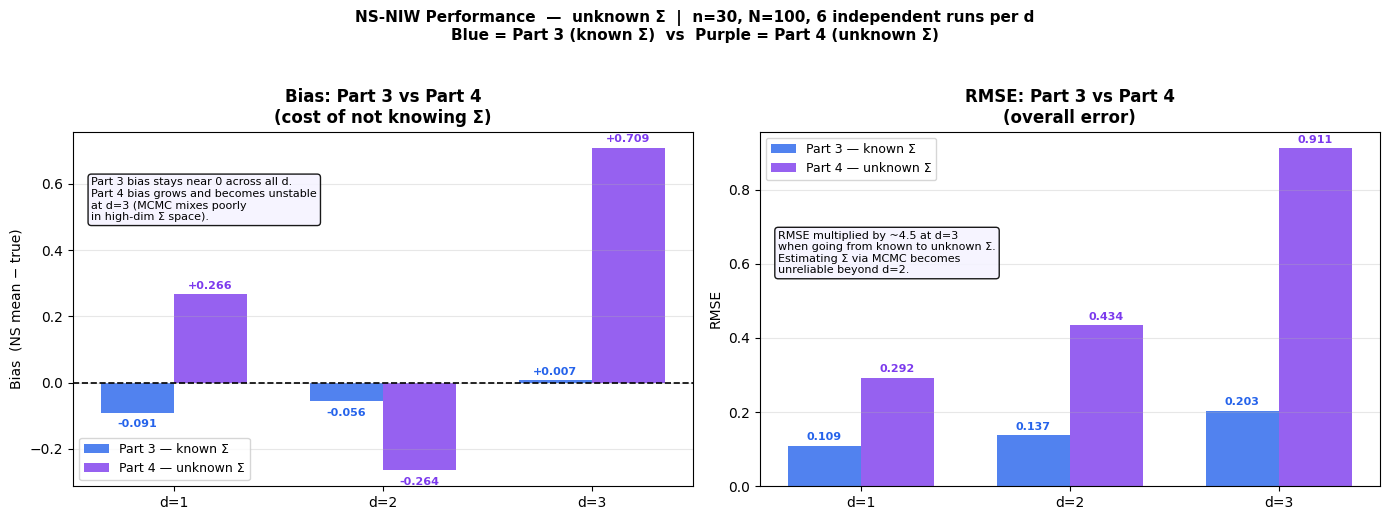

In [ ]:
# Plots for comparison

dims_q4   = [1, 2, 3]
trues_q4  = [-19.030, -65.898, -41.053]
means_q4  = [-18.764, -66.162, -40.344]
stds_q4   = [0.120,   0.344,   0.573]
biases_q4 = [+0.266,  -0.264,  +0.709]
rmses_q4  = [0.292,   0.434,   0.911]

dims_q3   = [1, 2, 3]
trues_q3  = [-37.976, -77.756, -141.507]
means_q3  = [-38.066, -77.812, -141.500]
stds_q3   = [0.060,   0.125,   0.203]
biases_q3 = [-0.091,  -0.056,  +0.007]
rmses_q3  = [0.109,   0.137,   0.203]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x      = np.arange(len(dims_q4))
labels = [f'd={d}' for d in dims_q4]
w      = 0.35

ax = axes[0] # Bias comparison Q3 vs Q4
bars3 = ax.bar(x - w/2, biases_q3, w, color='#2563eb', alpha=0.8, label='Part 3 — known Σ')
bars4 = ax.bar(x + w/2, biases_q4, w, color='#7c3aed', alpha=0.8, label='Part 4 — unknown Σ')
ax.axhline(0, color='black', lw=1.2, ls='--')
for bar, b in zip(bars3, biases_q3):
    ypos = b - 0.02 if b < 0 else b + 0.01
    va   = 'top' if b < 0 else 'bottom'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{b:+.3f}', ha='center', va=va, fontsize=8, color='#2563eb', fontweight='bold')
for bar, b in zip(bars4, biases_q4):
    ypos = b - 0.02 if b < 0 else b + 0.01
    va   = 'top' if b < 0 else 'bottom'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{b:+.3f}', ha='center', va=va, fontsize=8, color='#7c3aed', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Bias  (NS mean − true)')
ax.set_title('Bias: Part 3 vs Part 4\n(cost of not knowing Σ)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.annotate('Part 3 bias stays near 0 across all d.\nPart 4 bias grows and becomes unstable\nat d=3 (MCMC mixes poorly\nin high-dim Σ space).',
            xy=(0.03, 0.75), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#f5f3ff', alpha=0.9))

ax = axes[1] # RMSE comparison Q3 vs Q4
ax.bar(x - w/2, rmses_q3, w, color='#2563eb', alpha=0.8, label='Part 3 — known Σ')
ax.bar(x + w/2, rmses_q4, w, color='#7c3aed', alpha=0.8, label='Part 4 — unknown Σ')
for i, (r3, r4) in enumerate(zip(rmses_q3, rmses_q4)):
    ax.text(i - w/2, r3 + 0.01, f'{r3:.3f}', ha='center', va='bottom',
            fontsize=8, color='#2563eb', fontweight='bold')
    ax.text(i + w/2, r4 + 0.01, f'{r4:.3f}', ha='center', va='bottom',
            fontsize=8, color='#7c3aed', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('RMSE')
ax.set_title('RMSE: Part 3 vs Part 4\n(overall error)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.annotate('RMSE multiplied by ~4.5 at d=3\nwhen going from known to unknown Σ.\nEstimating Σ via MCMC becomes\nunreliable beyond d=2.',
            xy=(0.03, 0.60), xycoords='axes fraction', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='#f5f3ff', alpha=0.9))

fig.suptitle('NS-NIW Performance  —  unknown Σ  |  n=30, N=100, 6 independent runs per d\n'
             'Blue = Part 3 (known Σ)  vs  Purple = Part 4 (unknown Σ)',
             fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

These results illustrate a fundamental limitation of the part 4 algorithm. The practical performance degrades rapidly with dimension. The algorithm works reasonably at d=1 and remains acceptable at d=2, which is exactly what the problem statement anticipated when it noted that the method is only expected to work well for small d.